![Banner](../../images/07_banner.png)


# 7.6 Covariate-Assisted Interpolation

**Part:** 7 — Spatial Interpolation (Chapter 7.6 of 8)

**Dataset:** `diabetes_northeast.shp` (217 counties) — chosen because, unlike the PM2.5 network, it carries
genuinely predictive covariates alongside spatial coordinates

**Focus:** when do covariates beat pure spatial interpolation; GWR as an interpolator; regression kriging by hand

**Library:** `spatialstats.interpolate`, `spatialstats.gwmodel`, `spatialstats.regression` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [A Fair Comparison Needs a Shared Protocol](#3.-A-Fair-Comparison-Needs-a-Shared-Protocol)

4. [Spatial-Only Baselines](#4.-Spatial-Only-Baselines)

5. [GWR as an Interpolator](#5.-GWR-as-an-Interpolator)

6. [Regression Kriging by Hand](#6.-Regression-Kriging-by-Hand)

7. [When Do Covariates Actually Help?](#7.-When-Do-Covariates-Actually-Help?)

8. [Summary and Conclusions](#8.-Summary-and-Conclusions)

9. [Resources](#9.-Resources)


***
## 1. Overview

Every method in Chapters 7.3–7.5 used **only** spatial location — coordinates in, a prediction out, no other
information about *what* is being interpolated. But Part 6 spent fourteen chapters on models that use
covariates *and* space together. This chapter asks directly: on data where genuinely predictive covariates
exist, how much does letting a model use them actually help, compared with the best purely spatial method from
Chapter 7.5?

This chapter switches datasets deliberately — from the PM2.5 monitor network (no covariates available) to
`diabetes_northeast.shp`, the same 217-county dataset Part 6 built an entire geographically weighted model
family around. `Obesity` and `SVI` (the Social Vulnerability Index) are both strongly, independently associated
with `Dia_pct` in Part 3's own OLS fit — exactly the setting where covariate-assisted interpolation should have
real room to help.

| Step | What we do |
|------|------------|
| Baseline | The best purely spatial methods from Chapter 7.5 (IDW, kriging), refit here for `Dia_pct` |
| GWR as interpolator | `GWR.fit(X, y, coords).predict(X_new, coords_new)` used exactly like an `Interpolator` |
| Regression kriging by hand | Fit a global trend, krige the residuals, add the trend back — since this library does not implement it directly |
| The answer | A single shared spatial-block cross-validation protocol, so the comparison is actually fair |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.interpolate import IDW, OrdinaryKriging, cross_validate
from spatialstats.interpolate.validate import _folds
from spatialstats.gwmodel.linear import GWR
from spatialstats.regression import OLS

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

northeast = gpd.read_file(DATA / "diabetes_northeast.shp")
covariates = ["Obesity", "SVI"]
X = northeast[covariates]
y = northeast["Dia_pct"].to_numpy()
coords = northeast[["x", "y"]].to_numpy()
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. A Fair Comparison Needs a Shared Protocol

`GWR` is not a `spatialstats.interpolate.Interpolator` — it takes `(X, y, coords)` at `fit` time and
`(X_new, coords_new)` at `predict` time, not the `(coords, values)` interface `cross_validate` expects. To keep
the comparison fair, every method in this chapter is evaluated on **exactly the same spatial-block folds**,
built once with this library's own internal `_folds` helper (the same function `cross_validate` uses
internally) and reused for every model — spatial-only or covariate-assisted alike.

In [2]:
rng = np.random.default_rng(1)
folds = _folds(coords, "spatial_block", 10, 100_000, rng)
print(f"{len(folds)} spatial blocks, sizes: {[len(f) for f in folds]}")


def evaluate(pred, y):
    resid = pred - y
    sst = np.sum((y - y.mean()) ** 2)
    rmse = np.sqrt(np.mean(resid ** 2))
    r2 = 1 - np.sum(resid ** 2) / sst
    return rmse, r2

10 spatial blocks, sizes: [27, 18, 24, 16, 9, 24, 24, 26, 30, 19]


***
## 4. Spatial-Only Baselines

IDW and ordinary kriging, interpolating `Dia_pct` directly — no covariates, exactly like Chapter 7.5.

In [3]:
pred_idw = np.full(len(y), np.nan)
pred_krig = np.full(len(y), np.nan)
for test in folds:
    train = np.setdiff1d(np.arange(len(y)), test)
    idw = IDW(power=2, k=12); idw.fit(coords[train], y[train])
    pred_idw[test] = idw.predict(coords[test])
    krig = OrdinaryKriging(variogram="auto"); krig.fit(coords[train], y[train])
    pred_krig[test] = krig.predict(coords[test])

rmse_idw, r2_idw = evaluate(pred_idw, y)
rmse_krig, r2_krig = evaluate(pred_krig, y)
print(f"IDW (spatial only)     : RMSE={rmse_idw:.3f}  R2={r2_idw:.3f}")
print(f"kriging (spatial only) : RMSE={rmse_krig:.3f}  R2={r2_krig:.3f}")

IDW (spatial only)     : RMSE=1.097  R2=0.163
kriging (spatial only) : RMSE=1.101  R2=0.156


***
## 5. GWR as an Interpolator

`GWR` predicts $y$ at a new location from **both** its covariates and its position relative to the training
set's local relationships (Part 6, Chapter 6.5) — used here exactly as an interpolator, on the same folds.

In [4]:
pred_gwr = np.full(len(y), np.nan)
Xarr = X.to_numpy()
for test in folds:
    train = np.setdiff1d(np.arange(len(y)), test)
    m = GWR(bandwidth=60, fixed=False, kernel="bisquare", n_jobs=2)
    m.fit(Xarr[train], y[train], coords[train])
    pred_gwr[test] = m.predict(Xarr[test], coords[test])

rmse_gwr, r2_gwr = evaluate(pred_gwr, y)
print(f"GWR (covariate-assisted): RMSE={rmse_gwr:.3f}  R2={r2_gwr:.3f}")

GWR (covariate-assisted): RMSE=0.723  R2=0.637


***
## 6. Regression Kriging by Hand

Regression kriging — fit a global trend on covariates, krige the *residuals* from that trend, then add the
kriged residual surface back to the trend — is not implemented as a single class in this library, but is
straightforward to build from `spatialstats.regression.OLS` and `OrdinaryKriging` directly.

In [5]:
pred_rk = np.full(len(y), np.nan)
for test in folds:
    train = np.setdiff1d(np.arange(len(y)), test)
    ols = OLS(y[train], X.iloc[train])
    beta = ols.coef_frame()["coef"].to_numpy()

    X_train_design = np.column_stack([np.ones(len(train)), X.iloc[train].to_numpy()])
    X_test_design = np.column_stack([np.ones(len(test)), X.iloc[test].to_numpy()])
    trend_train = X_train_design @ beta
    trend_test = X_test_design @ beta

    krig = OrdinaryKriging(variogram="auto")
    krig.fit(coords[train], y[train] - trend_train)
    resid_pred = krig.predict(coords[test])
    pred_rk[test] = trend_test + resid_pred

rmse_rk, r2_rk = evaluate(pred_rk, y)
print(f"Regression kriging (by hand): RMSE={rmse_rk:.3f}  R2={r2_rk:.3f}")

Regression kriging (by hand): RMSE=0.722  R2=0.638


***
## 7. When Do Covariates Actually Help?

                         method   rmse     r2
0  Regression kriging (by hand)  0.722  0.638
1      GWR (covariate-assisted)  0.723  0.637
2            IDW (spatial only)  1.097  0.163
3        Kriging (spatial only)  1.101  0.156


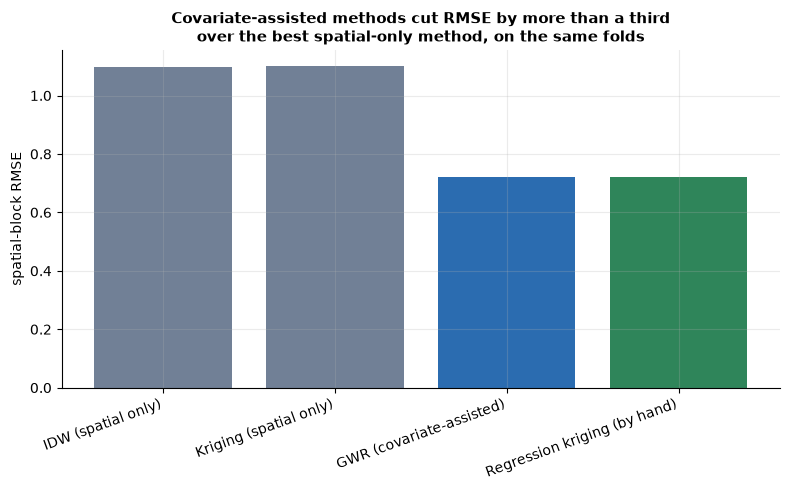

In [6]:
summary = pd.DataFrame({
    "method": ["IDW (spatial only)", "Kriging (spatial only)", "GWR (covariate-assisted)",
              "Regression kriging (by hand)"],
    "rmse": [rmse_idw, rmse_krig, rmse_gwr, rmse_rk],
    "r2": [r2_idw, r2_krig, r2_gwr, r2_rk],
}).sort_values("rmse").reset_index(drop=True)
print(summary.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
order = summary.set_index("method").loc[["IDW (spatial only)", "Kriging (spatial only)",
                                          "GWR (covariate-assisted)", "Regression kriging (by hand)"]]
ax.bar(range(len(order)), order["rmse"], color=[COLORS["grey"], COLORS["grey"], COLORS["blue"], COLORS["green"]])
ax.set_ylabel("spatial-block RMSE")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order.index, rotation=20, ha="right")
ax.set_title("Covariate-assisted methods cut RMSE by more than a third\nover the best spatial-only method, on the same folds")
plt.tight_layout()
plt.savefig("covariate_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

**Both covariate-assisted methods dramatically outperform both spatial-only baselines** — GWR and regression
kriging land within a hundredth of each other in RMSE, and both cut error by roughly a third compared with the
better spatial-only method (kriging). This is exactly what should happen when the covariates genuinely carry
independent predictive signal: `Obesity` and `SVI` explain patterns in `Dia_pct` that pure distance-based
smoothing has no way to see, no matter how well-calibrated the spatial method's uncertainty is (Chapter 7.4).

**This does not generalize automatically to the PM2.5 network from Chapters 7.3–7.5** — there, no covariates
were available at all, so "does covariate-assisted interpolation beat spatial-only" was never a meaningful
question to ask. The lesson here is conditional, not universal: **covariates help when they carry information
the spatial structure alone cannot recover** — check with a fair, shared cross-validation protocol like this
chapter's, on the specific data at hand, rather than assuming either direction by default.

***
## 8. Summary and Conclusions

This chapter asked whether letting a model use covariates, not just spatial location, actually improves
predictions — and answered it with a single, shared cross-validation protocol across four very different
methods.

### What we did

1. Built one shared set of spatial-block folds, since `GWR` and the `Interpolator` classes have different
   `fit`/`predict` signatures and cannot otherwise share `cross_validate` directly.
2. Established IDW and kriging spatial-only baselines on `diabetes_northeast.shp`'s `Dia_pct`.
3. Used `GWR` directly as an interpolator — `fit(X, y, coords)`, `predict(X_new, coords_new)` — on the identical
   folds.
4. **Built regression kriging by hand** (`OLS` trend + `OrdinaryKriging` on the residuals), since this library
   does not implement it as a single class.
5. **Found both covariate-assisted methods cut RMSE by roughly a third** compared with the better spatial-only
   baseline, and agree closely with each other — a clean, real demonstration of when covariates earn their keep.

### Practical takeaways

- When comparing methods with genuinely different interfaces, build the fold assignment once and reuse it
  explicitly — do not assume two different convenience functions use compatible splits.
- Regression kriging is easy to assemble from this library's existing pieces even without a dedicated class:
  `OLS` for the trend, `OrdinaryKriging` for the residual surface.
- Covariate-assisted interpolation is not automatically better — it is better exactly when the covariates carry
  real, spatially-decoupled predictive signal, which is an empirical question to check, not a default assumption.

### Next steps

**Chapter 7.7 (Areal Interpolation)** moves from point-to-point interpolation to a different transfer problem
entirely: moving data between two incompatible sets of polygons.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Hengl, T., Heuvelink, G. B. M. & Rossiter, D. G. (2007). About regression-kriging: From equations to case studies. *Computers & Geosciences*, 33, 1301–1315. | The regression-kriging construction built by hand in Section 6 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.gwmodel.linear.GWR` | Section 5 |
| `spatialstats.regression.OLS`, `spatialstats.interpolate.OrdinaryKriging` | Section 6's hand-built regression kriging |
| Part 6 | The full geographically weighted model family this chapter draws `GWR` from |
| Chapter 7.5 | The spatial-block protocol this chapter extends to non-`Interpolator` models |